In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

In [ ]:
# Đặt giới hạn số luồng xử lý cho mỗi thư viện tính toán về 1
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["VECLIB_MAXIMUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

--- QUÉT DỮ LIỆU VÀ LỌC (sig=0.5, h=10, K=5, Ka=3) ---
📂 Tìm thấy 36 file. Đang xử lý...
✅ Đã lọc dữ liệu thành công. Các method còn lại: ['CoRT-SI' 'Bonferroni' 'CoRT-SI-oc' 'DS' 'Naive' 'No inference']
   Các n_target tìm thấy: [np.int64(40), np.int64(50), np.int64(60), np.int64(70)]

--- Dữ liệu vẽ (Grouped) ---
          method n_target       fpr       tpr
0     Bonferroni       40  0.000000  0.061343
16         Naive       40  0.192857  0.558140
12            DS       40  0.077922  0.256177
4        CoRT-SI       40  0.042105  0.414912
8     CoRT-SI-oc       40  0.053333  0.050588
20  No inference       40  1.000000  1.000000
13            DS       50  0.056410  0.344099
17         Naive       50  0.141791  0.659353
9     CoRT-SI-oc       50  0.029762  0.039663
5        CoRT-SI       50  0.053333  0.533207
21  No inference       50  1.000000  1.000000
1     Bonferroni       50  0.000000  0.118192
10    CoRT-SI-oc       60  0.039474  0.043632
22  No inference       60  1.000000  1.

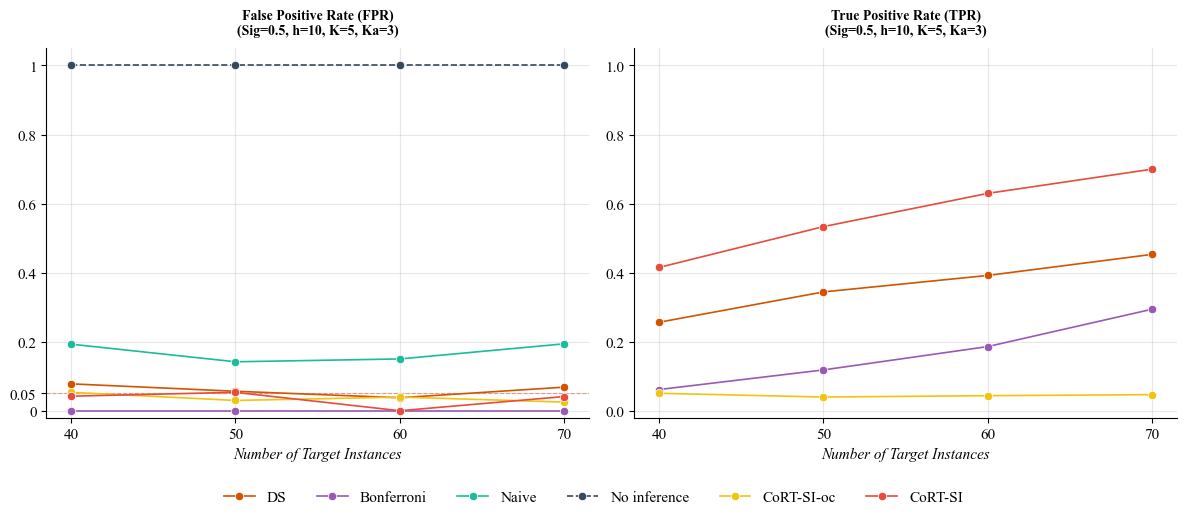

In [16]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import re

# ==============================================================================
# 1. CẤU HÌNH HỆ THỐNG & BỘ LỌC
# ==============================================================================
folders_to_scan = [
    'records/',                  
    'records_other_methods/'     
]
alpha = 0.05

# --- TRỤC HOÀNH: DANH SÁCH N_TARGET ---
n_target_list_ordered = [40, 50, 60, 70]

# --- QUAN TRỌNG: CỐ ĐỊNH CÁC THAM SỐ KHÁC ---
# Chỉ những file khớp với thông số này mới được vẽ (để so sánh công bằng)
# Hãy sửa các số này khớp với dữ liệu bạn muốn xem
fixed_signal = 0.5   
fixed_h = 10         
fixed_K = 5          
fixed_Ka = 3         

# Style vẽ hình
methods_config = {
    "DS":           {"color": "#d35400", "marker": "o", "ls": "-", "zorder": 3},
    "Bonferroni":   {"color": "#9b59b6", "marker": "o", "ls": "-", "zorder": 3},
    "Naive":        {"color": "#1abc9c", "marker": "o", "ls": "-", "zorder": 3},
    "No inference": {"color": "#34495e", "marker": "o", "ls": "--", "zorder": 2},
    "CoRT-SI-oc":   {"color": "#f1c40f", "marker": "o", "ls": "-", "zorder": 3},
    "CoRT-SI":      {"color": "#e74c3c", "marker": "o", "ls": "-", "zorder": 4} 
}

# ==============================================================================
# 2. HÀM TRÍCH XUẤT DỮ LIỆU (ROBUST)
# ==============================================================================
def get_param_from_config(cfg, param_name, filename=""):
    """
    Hàm tìm giá trị tham số từ config hoặc tên file (hỗ trợ nhiều định dạng)
    """
    # 1. Tìm trong config JSON
    if param_name in cfg:
        return float(cfg[param_name])
    
    # 2. Xử lý đặc biệt cho 'signal' (vì file CoRT-SI dùng s_vector)
    if param_name == 'signal':
        if 's_vector' in cfg and isinstance(cfg['s_vector'], list) and len(cfg['s_vector']) > 0:
            return float(cfg['s_vector'][0])
        # Fallback tên file: tìm _sig0.5_ hoặc _signal0.5_
        match = re.search(r'_sig([0-9\.]+)_', filename)
        if match: return float(match.group(1))
        match = re.search(r'_signal([0-9\.]+)_', filename)
        if match: return float(match.group(1))

    # 3. Fallback chung cho các tham số khác (Ka, K, h...) từ tên file
    pattern = rf'_{param_name}([0-9\.]+)_'
    match = re.search(pattern, filename)
    if match:
        return float(match.group(1))

    return None

def load_data_filtered():
    all_data = []
    all_files = []
    
    # Tạo chuỗi thông tin để in ra log
    filter_info = f"sig={fixed_signal}, h={fixed_h}, K={fixed_K}, Ka={fixed_Ka}"
    print(f"--- QUÉT DỮ LIỆU VÀ LỌC ({filter_info}) ---")

    for folder in folders_to_scan:
        if os.path.exists(folder):
            files = glob.glob(os.path.join(folder, '*.json'))
            all_files.extend(files)

    if not all_files:
        print("❌ Không tìm thấy file JSON nào!")
        return pd.DataFrame()

    print(f"📂 Tìm thấy {len(all_files)} file. Đang xử lý...")

    for filename in all_files:
        try:
            with open(filename, 'r') as f:
                content = json.load(f)
            
            items = content if isinstance(content, list) else [content]
            fname_base = os.path.basename(filename)
            
            # Xác định Method
            forced_method = None
            if "parametric_vis_records" in fname_base:
                forced_method = "CoRT-SI"

            for item in items:
                cfg = item.get("configs", {})
                
                # 1. Tên Method
                if forced_method:
                    method_name = forced_method
                elif "method" in cfg:
                    method_name = cfg["method"]
                else:
                    continue

                # 2. TRÍCH XUẤT VÀ LỌC THAM SỐ (Bước quan trọng)
                
                # --- Lọc Signal ---
                sig_val = get_param_from_config(cfg, 'signal', fname_base)
                if sig_val is not None and sig_val != fixed_signal: continue # Bỏ qua nếu không khớp

                # --- Lọc h ---
                h_val = get_param_from_config(cfg, 'h', fname_base)
                if h_val is not None and h_val != fixed_h: continue 

                # --- Lọc K ---
                K_val = get_param_from_config(cfg, 'K', fname_base)
                if K_val is not None and K_val != fixed_K: continue

                # --- Lọc Ka ---
                Ka_val = get_param_from_config(cfg, 'Ka', fname_base)
                if Ka_val is not None and Ka_val != fixed_Ka: continue

                # Lấy n_target (Trục hoành)
                n_tgt = cfg.get("n_target", 0)
                if n_tgt == 0: continue

                # 3. Lấy số liệu
                if "raw_counts" in item:
                    counts = item["raw_counts"]
                else:
                    counts = {
                        "is_signal_cases": item.get("is_signal_cases", 0),
                        "not_signal_cases": item.get("not_signal_cases", 0),
                        "true_positives": item.get("true_positives", 0),
                        "false_positives": item.get("false_positives", 0)
                    }

                all_data.append({
                    "method": method_name,
                    "n_target": n_tgt,
                    **counts
                })
                        
        except Exception as e:
            pass
            
    return pd.DataFrame(all_data)

# ==============================================================================
# 3. XỬ LÝ VÀ VẼ HÌNH
# ==============================================================================
df_raw = load_data_filtered()

if df_raw.empty:
    print("❌ Không có dữ liệu hợp lệ sau khi lọc.")
    print("👉 Hãy kiểm tra lại các biến 'fixed_...' xem có khớp với file JSON không.")
else:
    print(f"✅ Đã lọc dữ liệu thành công. Các method còn lại: {df_raw['method'].unique()}")
    print(f"   Các n_target tìm thấy: {sorted(df_raw['n_target'].unique())}")

    # --- GOM NHÓM THEO n_target ---
    group_cols = ['method', 'n_target']
    df_grouped = df_raw.groupby(group_cols)[['is_signal_cases', 'not_signal_cases', 'true_positives', 'false_positives']].sum().reset_index()

    # Tính FPR / TPR
    df_grouped['fpr'] = df_grouped.apply(lambda x: x['false_positives']/x['not_signal_cases'] if x['not_signal_cases']>0 else 0, axis=1)
    df_grouped['tpr'] = df_grouped.apply(lambda x: x['true_positives']/x['is_signal_cases'] if x['is_signal_cases']>0 else 0, axis=1)

    # Lọc theo danh sách n_target mong muốn và sắp xếp
    df_grouped = df_grouped[df_grouped['n_target'].isin(n_target_list_ordered)]
    df_grouped['n_target'] = pd.Categorical(df_grouped['n_target'], categories=n_target_list_ordered, ordered=True)
    df_grouped = df_grouped.sort_values(['n_target'])
    
    print("\n--- Dữ liệu vẽ (Grouped) ---")
    print(df_grouped[['method', 'n_target', 'fpr', 'tpr']])

    # --- VẼ BIỂU ĐỒ ---
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.linewidth'] = 0.8

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    def format_func(value, tick_number):
        if abs(value - alpha) < 1e-9: return f'{alpha}'
        if value == 0.0: return '0'
        if value == 1.0: return '1'
        return f'{value:.1f}'

    # Title phụ hiển thị thông tin cấu hình
    subtitle = f"(Sig={fixed_signal}, h={fixed_h}, K={fixed_K}, Ka={fixed_Ka})"

    # === FPR ===
    ax1.axhline(y=alpha, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
    
    found_methods = df_grouped['method'].unique()
    for name in methods_config.keys():
        if name not in found_methods: continue
        
        data = df_grouped[df_grouped['method'] == name]
        cfg = methods_config[name]
        
        ax1.plot(data['n_target'], data["fpr"], 
                 label=name, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], 
                 markersize=6, linewidth=1.2, markeredgecolor='white', markeredgewidth=0.5,
                 zorder=cfg["zorder"])

    ax1.set_xticks(n_target_list_ordered)
    ax1.set_yticks([0.0, 0.05, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax1.yaxis.set_major_formatter(FuncFormatter(format_func))
    
    ax1.set_title(f"False Positive Rate (FPR)\n{subtitle}", fontweight='bold', pad=10, fontsize=10)
    ax1.set_xlabel("Number of Target Instances", style='italic')
    ax1.set_ylim(-0.02, 1.05)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(True, alpha=0.3)

    # === TPR ===
    for name in methods_config.keys():
        if name not in found_methods: continue
        if name in ["Naive", "No inference"]: continue 
        
        data = df_grouped[df_grouped['method'] == name]
        cfg = methods_config[name]
        
        ax2.plot(data['n_target'], data["tpr"], 
                 label=name, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], 
                 markersize=6, linewidth=1.2, markeredgecolor='white', markeredgewidth=0.5,
                 zorder=cfg["zorder"])

    ax2.set_xticks(n_target_list_ordered)
    ax2.set_title(f"True Positive Rate (TPR)\n{subtitle}", fontweight='bold', pad=10, fontsize=10)
    ax2.set_xlabel("Number of Target Instances", style='italic')
    ax2.set_ylim(-0.02, 1.05)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(True, alpha=0.3)

    # === LEGEND ===
    handles, labels = ax1.get_legend_handles_labels()
    ordered_handles = []
    ordered_labels = []
    for method_name in methods_config.keys():
        if method_name in labels:
            idx = labels.index(method_name)
            ordered_handles.append(handles[idx])
            ordered_labels.append(labels[idx])

    fig.legend(ordered_handles, ordered_labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=6, frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

--- BẮT ĐẦU QUÉT DỮ LIỆU ---
📂 Tìm thấy 28 file. Đang xử lý...
✅ Đang vẽ biểu đồ tại n_target = 40

--- Bảng dữ liệu vẽ (Grouped) ---
          method  signal       fpr       tpr
0     Bonferroni    0.25  0.000000  0.005637
4        CoRT-SI    0.25  0.071823  0.149270
12            DS    0.25  0.065574  0.101591
8     CoRT-SI-oc    0.25  0.034722  0.039720
20  No inference    0.25  1.000000  1.000000
16         Naive    0.25  0.155844  0.160757
9     CoRT-SI-oc    0.50  0.052980  0.047114
13            DS    0.50  0.059633  0.210997
17         Naive    0.50  0.120301  0.542099
21  No inference    0.50  1.000000  1.000000
5        CoRT-SI    0.50  0.056818  0.433036
1     Bonferroni    0.50  0.000000  0.063830
14            DS    0.75  0.086066  0.433862
10    CoRT-SI-oc    0.75  0.050420  0.048808
2     Bonferroni    0.75  0.000000  0.331422
6        CoRT-SI    0.75  0.043103  0.754513
22  No inference    0.75  1.000000  1.000000
18         Naive    0.75  0.141791  0.869515
3     Bonfe

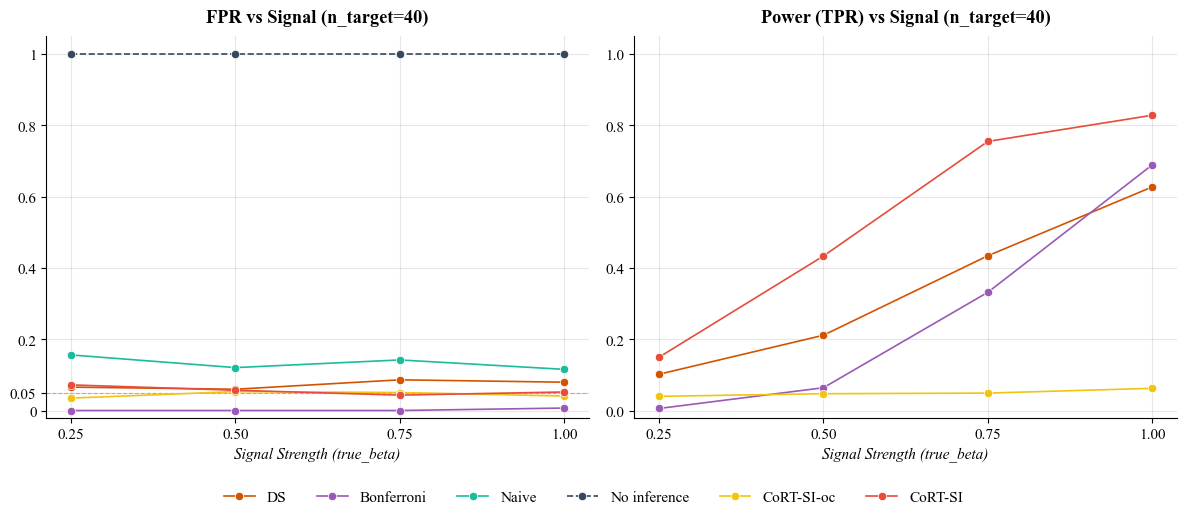

In [ ]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import re

# ==============================================================================
# 1. CẤU HÌNH HỆ THỐNG
# ==============================================================================
# Danh sách thư mục chứa file kết quả
folders_to_scan = [
    'records_2/',                  
    'records_other_methods_2/'     
]

alpha = 0.05

# --- CẤU HÌNH VẼ ---
# Danh sách các mức Signal muốn hiển thị trên trục hoành
signal_list_ordered = [0.25, 0.5, 0.75, 1.0]

# QUAN TRỌNG: Chọn một n_target cố định để vẽ biểu đồ theo Signal
# (Bạn cần đảm bảo đã chạy thực nghiệm tại n_target này với đủ các mức signal trên)
fixed_n_target = 40 

# Style vẽ hình
methods_config = {
    "DS":           {"color": "#d35400", "marker": "o", "ls": "-", "zorder": 3},
    "Bonferroni":   {"color": "#9b59b6", "marker": "o", "ls": "-", "zorder": 3},
    "Naive":        {"color": "#1abc9c", "marker": "o", "ls": "-", "zorder": 3},
    "No inference": {"color": "#34495e", "marker": "o", "ls": "--", "zorder": 2},
    "CoRT-SI-oc":   {"color": "#f1c40f", "marker": "o", "ls": "-", "zorder": 3},
    "CoRT-SI":      {"color": "#e74c3c", "marker": "o", "ls": "-", "zorder": 4} 
}

# ==============================================================================
# 2. HÀM TRÍCH XUẤT DỮ LIỆU
# ==============================================================================
def get_signal_from_config(cfg, filename=""):
    """
    Hàm thông minh để tìm giá trị signal từ nhiều nguồn khác nhau
    """
    # Ưu tiên 1: Lấy trực tiếp key 'signal' (thường có trong DS, Naive...)
    if 'signal' in cfg:
        return float(cfg['signal'])
    
    # Ưu tiên 2: Lấy từ s_vector (đặc thù của CoRT-SI)
    if 's_vector' in cfg:
        vec = cfg['s_vector']
        if isinstance(vec, list) and len(vec) > 0:
            return float(vec[0]) # Lấy giá trị đầu tiên của vector
            
    # Ưu tiên 3: Nếu không có trong config, thử quét từ tên file (fallback)
    # Ví dụ tên file: ..._sig0.5_...
    match = re.search(r'_sig([0-9\.]+)_', filename)
    if match:
        return float(match.group(1))
        
    return None

def load_data_by_signal():
    all_data = []
    all_files = []
    
    # Quét file
    print("--- BẮT ĐẦU QUÉT DỮ LIỆU ---")
    for folder in folders_to_scan:
        if os.path.exists(folder):
            files = glob.glob(os.path.join(folder, '*.json'))
            all_files.extend(files)
        else:
            print(f"⚠️ Không tìm thấy thư mục '{folder}'")

    if not all_files:
        print("❌ Không tìm thấy file JSON nào!")
        return pd.DataFrame()

    print(f"📂 Tìm thấy {len(all_files)} file. Đang xử lý...")

    for filename in all_files:
        try:
            with open(filename, 'r') as f:
                content = json.load(f)
            
            # Chuẩn hóa thành list
            items = content if isinstance(content, list) else [content]
            fname_base = os.path.basename(filename)
            
            # Xác định Method (CoRT-SI hoặc các method khác)
            forced_method = None
            if "parametric_vis_records" in fname_base:
                forced_method = "CoRT-SI"

            for item in items:
                cfg = item.get("configs", {})
                
                # 1. Xác định Tên Method
                if forced_method:
                    method_name = forced_method
                elif "method" in cfg:
                    method_name = cfg["method"]
                else:
                    continue # Bỏ qua nếu không biết method là gì

                # 2. Xác định n_target
                n_tgt = cfg.get("n_target", 0)
                
                # 3. Xác định Signal (QUAN TRỌNG)
                sig_val = get_signal_from_config(cfg, fname_base)
                
                if sig_val is None:
                    continue # Bỏ qua nếu không tìm thấy signal

                # 4. Lấy số liệu counts
                if "raw_counts" in item:
                    counts = item["raw_counts"]
                else:
                    counts = {
                        "is_signal_cases": item.get("is_signal_cases", 0),
                        "not_signal_cases": item.get("not_signal_cases", 0),
                        "true_positives": item.get("true_positives", 0),
                        "false_positives": item.get("false_positives", 0)
                    }

                # Lưu vào danh sách
                all_data.append({
                    "method": method_name,
                    "n_target": n_tgt,
                    "signal": sig_val,
                    **counts
                })
                        
        except Exception as e:
            # print(f"⚠️ Lỗi file {filename}: {e}")
            pass
            
    return pd.DataFrame(all_data)

# ==============================================================================
# 3. XỬ LÝ VÀ VẼ HÌNH
# ==============================================================================
df_raw = load_data_by_signal()

if df_raw.empty:
    print("❌ Không có dữ liệu hợp lệ.")
else:
    # --- BƯỚC 1: LỌC DỮ LIỆU THEO N_TARGET ---
    # Chỉ lấy dữ liệu của n_target cố định (VD: 50)
    df_plot = df_raw[df_raw['n_target'] == fixed_n_target].copy()
    
    if df_plot.empty:
        print(f"❌ Không tìm thấy dữ liệu nào tại n_target = {fixed_n_target}")
        print(f"   (Các n_target tìm thấy: {sorted(df_raw['n_target'].unique())})")
    else:
        print(f"✅ Đang vẽ biểu đồ tại n_target = {fixed_n_target}")
        
        # --- BƯỚC 2: GOM NHÓM THEO SIGNAL ---
        # Group by [Method, Signal] và tính tổng
        group_cols = ['method', 'signal']
        df_grouped = df_plot.groupby(group_cols)[['is_signal_cases', 'not_signal_cases', 'true_positives', 'false_positives']].sum().reset_index()

        # Tính FPR / TPR
        df_grouped['fpr'] = df_grouped.apply(lambda x: x['false_positives']/x['not_signal_cases'] if x['not_signal_cases']>0 else 0, axis=1)
        df_grouped['tpr'] = df_grouped.apply(lambda x: x['true_positives']/x['is_signal_cases'] if x['is_signal_cases']>0 else 0, axis=1)

        # Chỉ giữ lại các signal có trong danh sách cấu hình (0.25, 0.5...)
        # Lưu ý: làm tròn signal đôi khi cần thiết để khớp floating point
        df_grouped['signal'] = df_grouped['signal'].round(2) 
        df_grouped = df_grouped[df_grouped['signal'].isin(signal_list_ordered)]
        
        # Sắp xếp tăng dần theo signal
        df_grouped = df_grouped.sort_values(['signal'])
        
        # In kiểm tra
        print("\n--- Bảng dữ liệu vẽ (Grouped) ---")
        print(df_grouped[['method', 'signal', 'fpr', 'tpr']])

        # --- BƯỚC 3: VẼ BIỂU ĐỒ ---
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman']
        plt.rcParams['font.size'] = 11
        plt.rcParams['axes.linewidth'] = 0.8

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        def format_func(value, tick_number):
            if abs(value - alpha) < 1e-9: return f'{alpha}'
            if value == 0.0: return '0'
            if value == 1.0: return '1'
            return f'{value:.1f}'

        # === BIỂU ĐỒ 1: FPR vs SIGNAL ===
        ax1.axhline(y=alpha, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
        
        found_methods = df_grouped['method'].unique()
        for name in methods_config.keys():
            if name not in found_methods: continue
            
            data = df_grouped[df_grouped['method'] == name]
            cfg = methods_config[name]
            
            ax1.plot(data['signal'], data["fpr"], 
                     label=name, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], 
                     markersize=6, linewidth=1.2, markeredgecolor='white', markeredgewidth=0.5,
                     zorder=cfg["zorder"])

        ax1.set_xticks(signal_list_ordered)
        ax1.set_yticks([0.0, 0.05, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax1.yaxis.set_major_formatter(FuncFormatter(format_func))
        
        ax1.set_title(f"FPR vs Signal (n_target={fixed_n_target})", fontweight='bold', pad=10)
        ax1.set_xlabel("Signal Strength (true_beta)", style='italic')
        ax1.set_ylim(-0.02, 1.05)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(True, alpha=0.3)

        # === BIỂU ĐỒ 2: TPR vs SIGNAL ===
        for name in methods_config.keys():
            if name not in found_methods: continue
            if name in ["Naive", "No inference"]: continue 
            
            data = df_grouped[df_grouped['method'] == name]
            cfg = methods_config[name]
            
            ax2.plot(data['signal'], data["tpr"], 
                     label=name, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], 
                     markersize=6, linewidth=1.2, markeredgecolor='white', markeredgewidth=0.5,
                     zorder=cfg["zorder"])

        ax2.set_xticks(signal_list_ordered)
        ax2.set_title(f"Power (TPR) vs Signal (n_target={fixed_n_target})", fontweight='bold', pad=10)
        ax2.set_xlabel("Signal Strength (true_beta)", style='italic')
        ax2.set_ylim(-0.02, 1.05)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(True, alpha=0.3)

        # === LEGEND ===
        handles, labels = ax1.get_legend_handles_labels()
        ordered_handles = []
        ordered_labels = []
        for method_name in methods_config.keys():
            if method_name in labels:
                idx = labels.index(method_name)
                ordered_handles.append(handles[idx])
                ordered_labels.append(labels[idx])

        fig.legend(ordered_handles, ordered_labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=6, frameon=False)

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.15)
        plt.show()

--- BẮT ĐẦU QUÉT DỮ LIỆU (n=40, sig=0.5) ---
📂 Tìm thấy 28 file. Đang xử lý...
✅ Đã lọc dữ liệu. Các method tìm thấy: ['CoRT-SI' 'Bonferroni' 'CoRT-SI-oc' 'DS' 'Naive' 'No inference']

--- Bảng dữ liệu vẽ (Grouped) ---
          method     h       fpr       tpr
0     Bonferroni   2.0  0.000000  0.060819
4        CoRT-SI   2.0  0.060606  0.451064
12            DS   2.0  0.087179  0.227329
8     CoRT-SI-oc   2.0  0.048780  0.043330
20  No inference   2.0  1.000000  1.000000
16         Naive   2.0  0.136752  0.556059
9     CoRT-SI-oc   6.0  0.034483  0.080702
13            DS   6.0  0.053061  0.226490
17         Naive   6.0  0.072993  0.535342
21  No inference   6.0  1.000000  1.000000
5        CoRT-SI   6.0  0.026667  0.433839
1     Bonferroni   6.0  0.000000  0.054210
14            DS  10.0  0.073171  0.223899
10    CoRT-SI-oc  10.0  0.042857  0.060465
2     Bonferroni  10.0  0.000000  0.070258
6        CoRT-SI  10.0  0.046512  0.463351
22  No inference  10.0  1.000000  1.000000
18     

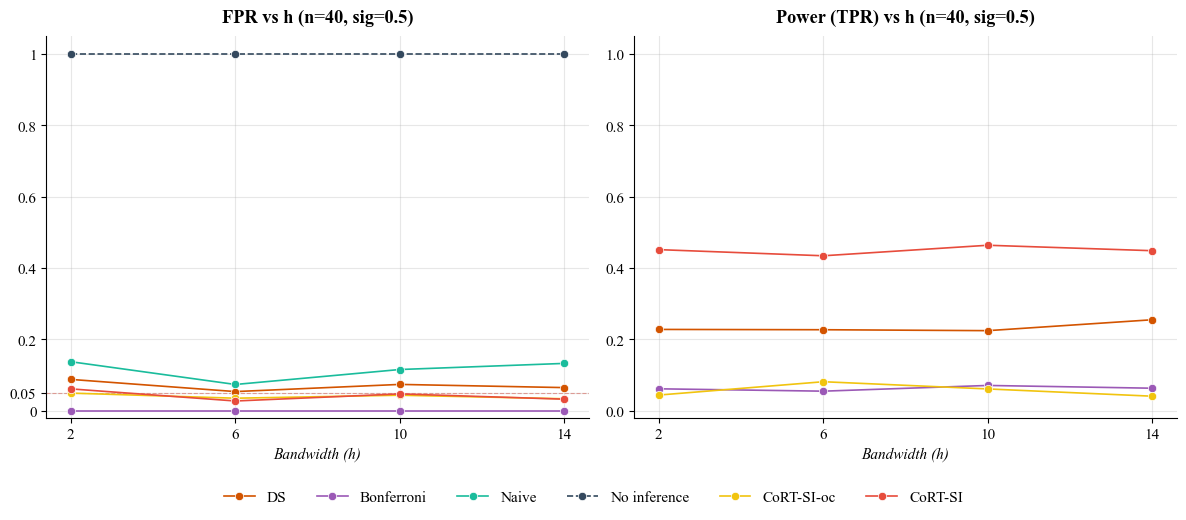

In [12]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import re

# ==============================================================================
# 1. CẤU HÌNH HỆ THỐNG
# ==============================================================================
folders_to_scan = [
    'records_3/',                  
    'records_other_methods_3/'     
]

alpha = 0.05

# --- CẤU HÌNH TRỤC HOÀNH (h) ---
h_list_ordered = [2, 6, 10, 14] 

# --- QUAN TRỌNG: CỐ ĐỊNH CÁC THAM SỐ KHÁC ---
# Dựa trên ảnh bạn gửi, bạn đang vẽ cho n=40 và sig=0.5
fixed_n_target = 40   # <--- Hãy đảm bảo số này khớp với file bạn có (40, 50, v.v.)
fixed_signal = 0.5    

# Style vẽ hình
methods_config = {
    "DS":           {"color": "#d35400", "marker": "o", "ls": "-", "zorder": 3},
    "Bonferroni":   {"color": "#9b59b6", "marker": "o", "ls": "-", "zorder": 3},
    "Naive":        {"color": "#1abc9c", "marker": "o", "ls": "-", "zorder": 3},
    "No inference": {"color": "#34495e", "marker": "o", "ls": "--", "zorder": 2},
    "CoRT-SI-oc":   {"color": "#f1c40f", "marker": "o", "ls": "-", "zorder": 3},
    "CoRT-SI":      {"color": "#e74c3c", "marker": "o", "ls": "-", "zorder": 4} 
}

# ==============================================================================
# 2. HÀM TRÍCH XUẤT DỮ LIỆU (ĐÃ SỬA LỖI ĐỌC TÊN FILE)
# ==============================================================================
def get_param_from_config(cfg, param_name, filename=""):
    """
    Hàm tìm giá trị tham số an toàn từ config hoặc tên file
    """
    # 1. Ưu tiên tìm trong nội dung file JSON (config)
    if param_name in cfg:
        return float(cfg[param_name])
    
    # 2. Xử lý đặc biệt cho 'signal' (vì file CoRT-SI dùng s_vector)
    if param_name == 'signal':
        if 's_vector' in cfg and isinstance(cfg['s_vector'], list) and len(cfg['s_vector']) > 0:
            return float(cfg['s_vector'][0])
        
        # Fallback: Tìm trong tên file (Hỗ trợ cả '_sig' và '_signal')
        # Đây là chỗ sửa lỗi: thêm pattern tìm '_sig'
        match = re.search(r'_sig([0-9\.]+)_', filename)
        if match: return float(match.group(1))
        
        match = re.search(r'_signal([0-9\.]+)_', filename)
        if match: return float(match.group(1))

    # 3. Fallback chung cho các tham số khác (như h, Ka...)
    # Tìm pattern dạng _h10_ hoặc _Ka2_
    pattern = rf'_{param_name}([0-9\.]+)_'
    match = re.search(pattern, filename)
    if match:
        return float(match.group(1))

    return None

def load_data_by_h():
    all_data = []
    all_files = []
    
    print(f"--- BẮT ĐẦU QUÉT DỮ LIỆU (n={fixed_n_target}, sig={fixed_signal}) ---")
    for folder in folders_to_scan:
        if os.path.exists(folder):
            files = glob.glob(os.path.join(folder, '*.json'))
            all_files.extend(files)

    if not all_files:
        print("❌ Không tìm thấy file JSON nào!")
        return pd.DataFrame()

    print(f"📂 Tìm thấy {len(all_files)} file. Đang xử lý...")

    for filename in all_files:
        try:
            with open(filename, 'r') as f:
                content = json.load(f)
            
            items = content if isinstance(content, list) else [content]
            fname_base = os.path.basename(filename)
            
            # Tự động nhận diện CoRT-SI qua tên file
            forced_method = None
            if "parametric_vis_records" in fname_base:
                forced_method = "CoRT-SI"

            for item in items:
                cfg = item.get("configs", {})
                
                # 1. Tên Method
                if forced_method:
                    method_name = forced_method
                elif "method" in cfg:
                    method_name = cfg["method"]
                else:
                    continue

                # 2. Lấy các tham số quan trọng
                n_tgt = cfg.get("n_target", 0)
                
                # Lấy h
                h_val = get_param_from_config(cfg, 'h', fname_base)
                
                # Lấy signal
                sig_val = get_param_from_config(cfg, 'signal', fname_base)
                if sig_val is None: sig_val = 0 # Default nếu không tìm thấy
                
                if h_val is None: continue

                # 3. Lấy số liệu
                if "raw_counts" in item:
                    counts = item["raw_counts"]
                else:
                    counts = {
                        "is_signal_cases": item.get("is_signal_cases", 0),
                        "not_signal_cases": item.get("not_signal_cases", 0),
                        "true_positives": item.get("true_positives", 0),
                        "false_positives": item.get("false_positives", 0)
                    }

                all_data.append({
                    "method": method_name,
                    "n_target": n_tgt,
                    "h": h_val,
                    "signal": sig_val,
                    **counts
                })
                        
        except Exception as e:
            pass
            
    return pd.DataFrame(all_data)

# ==============================================================================
# 3. XỬ LÝ VÀ VẼ HÌNH
# ==============================================================================
df_raw = load_data_by_h()

if df_raw.empty:
    print("❌ Không có dữ liệu hợp lệ.")
else:
    # --- BƯỚC 1: LỌC DỮ LIỆU ---
    # Lọc theo n_target và signal cố định
    df_plot = df_raw[
        (df_raw['n_target'] == fixed_n_target) & 
        (df_raw['signal'] == fixed_signal)
    ].copy()
    
    if df_plot.empty:
        print(f"❌ Không tìm thấy dữ liệu khớp: n_target={fixed_n_target}, signal={fixed_signal}")
        print("   Gợi ý: Kiểm tra lại biến 'fixed_n_target' ở đầu file xem có khớp với file JSON không.")
        print(f"   Các n_target tìm thấy trong file: {sorted(df_raw['n_target'].unique())}")
    else:
        print(f"✅ Đã lọc dữ liệu. Các method tìm thấy: {df_plot['method'].unique()}")
        
        # --- BƯỚC 2: GOM NHÓM THEO h ---
        group_cols = ['method', 'h']
        df_grouped = df_plot.groupby(group_cols)[['is_signal_cases', 'not_signal_cases', 'true_positives', 'false_positives']].sum().reset_index()

        # Tính FPR / TPR
        df_grouped['fpr'] = df_grouped.apply(lambda x: x['false_positives']/x['not_signal_cases'] if x['not_signal_cases']>0 else 0, axis=1)
        df_grouped['tpr'] = df_grouped.apply(lambda x: x['true_positives']/x['is_signal_cases'] if x['is_signal_cases']>0 else 0, axis=1)

        # Lọc theo h_list mong muốn
        df_grouped = df_grouped[df_grouped['h'].isin(h_list_ordered)]
        df_grouped = df_grouped.sort_values(['h'])
        
        print("\n--- Bảng dữ liệu vẽ (Grouped) ---")
        print(df_grouped[['method', 'h', 'fpr', 'tpr']])

        # --- BƯỚC 3: VẼ BIỂU ĐỒ ---
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman']
        plt.rcParams['font.size'] = 11
        plt.rcParams['axes.linewidth'] = 0.8

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        def format_func(value, tick_number):
            if abs(value - alpha) < 1e-9: return f'{alpha}'
            if value == 0.0: return '0'
            if value == 1.0: return '1'
            return f'{value:.1f}'

        # === FPR ===
        ax1.axhline(y=alpha, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
        
        found_methods = df_grouped['method'].unique()
        for name in methods_config.keys():
            if name not in found_methods: continue
            
            data = df_grouped[df_grouped['method'] == name]
            cfg = methods_config[name]
            
            ax1.plot(data['h'], data["fpr"], 
                     label=name, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], 
                     markersize=6, linewidth=1.2, markeredgecolor='white', markeredgewidth=0.5,
                     zorder=cfg["zorder"])

        ax1.set_xticks(h_list_ordered)
        ax1.set_yticks([0.0, 0.05, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax1.yaxis.set_major_formatter(FuncFormatter(format_func))
        
        ax1.set_title(f"FPR vs h (n={fixed_n_target}, sig={fixed_signal})", fontweight='bold', pad=10)
        ax1.set_xlabel("Bandwidth (h)", style='italic')
        ax1.set_ylim(-0.02, 1.05)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(True, alpha=0.3)

        # === TPR ===
        for name in methods_config.keys():
            if name not in found_methods: continue
            if name in ["Naive", "No inference"]: continue 
            
            data = df_grouped[df_grouped['method'] == name]
            cfg = methods_config[name]
            
            ax2.plot(data['h'], data["tpr"], 
                     label=name, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], 
                     markersize=6, linewidth=1.2, markeredgecolor='white', markeredgewidth=0.5,
                     zorder=cfg["zorder"])

        ax2.set_xticks(h_list_ordered)
        ax2.set_title(f"Power (TPR) vs h (n={fixed_n_target}, sig={fixed_signal})", fontweight='bold', pad=10)
        ax2.set_xlabel("Bandwidth (h)", style='italic')
        ax2.set_ylim(-0.02, 1.05)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(True, alpha=0.3)

        # === LEGEND ===
        handles, labels = ax1.get_legend_handles_labels()
        ordered_handles = []
        ordered_labels = []
        for method_name in methods_config.keys():
            if method_name in labels:
                idx = labels.index(method_name)
                ordered_handles.append(handles[idx])
                ordered_labels.append(labels[idx])

        fig.legend(ordered_handles, ordered_labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=6, frameon=False)

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.15)
        plt.show()

--- QUÉT DỮ LIỆU (n=40, sig=0.5, h=10, K=7) ---
📂 Tìm thấy 21 file. Đang xử lý...
✅ Đang vẽ biểu đồ theo Ka (n=40, sig=0.5, K=7)

--- Dữ liệu vẽ (Grouped) ---
          method   Ka       fpr       tpr
0     Bonferroni  1.0  0.000000  0.066026
4        CoRT-SI  1.0  0.059524  0.353211
12            DS  1.0  0.171687  0.227545
8     CoRT-SI-oc  1.0  0.056497  0.038882
20  No inference  1.0  1.000000  1.000000
16         Naive  1.0  0.180488  0.525786
9     CoRT-SI-oc  3.0  0.023810  0.049199
13            DS  3.0  0.079422  0.242047
17         Naive  3.0  0.132450  0.577150
21  No inference  3.0  1.000000  1.000000
5        CoRT-SI  3.0  0.070423  0.458797
1     Bonferroni  3.0  0.000000  0.064403
14            DS  5.0  0.080214  0.217712
10    CoRT-SI-oc  5.0  0.053030  0.042627
2     Bonferroni  5.0  0.000000  0.074679
6        CoRT-SI  5.0  0.057692  0.433761
22  No inference  5.0  1.000000  1.000000
18         Naive  5.0  0.082090  0.595843
3     Bonferroni  7.0  0.000000  0.062358
7

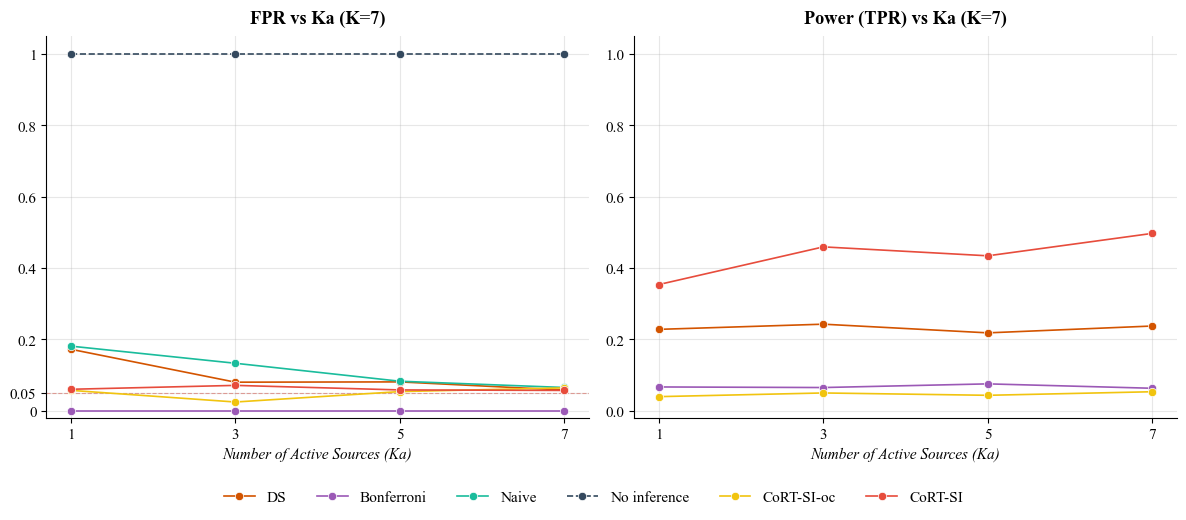

In [13]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import re

# ==============================================================================
# 1. CẤU HÌNH HỆ THỐNG
# ==============================================================================
folders_to_scan = [
    'records_4/',                  
    'records_other_methods_4/'     
]

alpha = 0.05

# --- CẤU HÌNH TRỤC HOÀNH (Ka) ---
Ka_list_ordered = [1, 3, 5, 7] 

# --- QUAN TRỌNG: CỐ ĐỊNH CÁC THAM SỐ KHÁC ---
# Chỉ lấy dữ liệu khớp với các thông số này để so sánh công bằng
fixed_n_target = 40   # Bạn kiểm tra lại xem mình chạy n=40 hay 50
fixed_signal = 0.5
fixed_h = 10
fixed_K = 7           # Yêu cầu mới của bạn

# Style vẽ hình
methods_config = {
    "DS":           {"color": "#d35400", "marker": "o", "ls": "-", "zorder": 3},
    "Bonferroni":   {"color": "#9b59b6", "marker": "o", "ls": "-", "zorder": 3},
    "Naive":        {"color": "#1abc9c", "marker": "o", "ls": "-", "zorder": 3},
    "No inference": {"color": "#34495e", "marker": "o", "ls": "--", "zorder": 2},
    "CoRT-SI-oc":   {"color": "#f1c40f", "marker": "o", "ls": "-", "zorder": 3},
    "CoRT-SI":      {"color": "#e74c3c", "marker": "o", "ls": "-", "zorder": 4} 
}

# ==============================================================================
# 2. HÀM TRÍCH XUẤT DỮ LIỆU
# ==============================================================================
def get_param_from_config(cfg, param_name, filename=""):
    """
    Hàm tìm giá trị tham số (Ka, K, h, signal...) từ config hoặc tên file
    """
    # 1. Tìm trong config
    if param_name in cfg:
        return float(cfg[param_name])
    
    # 2. Xử lý đặc biệt cho 'signal' (vì file CoRT-SI dùng s_vector)
    if param_name == 'signal':
        if 's_vector' in cfg and isinstance(cfg['s_vector'], list) and len(cfg['s_vector']) > 0:
            return float(cfg['s_vector'][0])
        # Fallback tên file
        match = re.search(r'_sig([0-9\.]+)_', filename)
        if match: return float(match.group(1))
        match = re.search(r'_signal([0-9\.]+)_', filename)
        if match: return float(match.group(1))

    # 3. Fallback chung cho các tham số khác (Ka, K, h...)
    # Tìm pattern dạng _Ka3_ hoặc _K7_
    pattern = rf'_{param_name}([0-9\.]+)_'
    match = re.search(pattern, filename)
    if match:
        return float(match.group(1))

    return None

def load_data_by_Ka():
    all_data = []
    all_files = []
    
    print(f"--- QUÉT DỮ LIỆU (n={fixed_n_target}, sig={fixed_signal}, h={fixed_h}, K={fixed_K}) ---")
    for folder in folders_to_scan:
        if os.path.exists(folder):
            files = glob.glob(os.path.join(folder, '*.json'))
            all_files.extend(files)

    if not all_files:
        print("❌ Không tìm thấy file JSON nào!")
        return pd.DataFrame()

    print(f"📂 Tìm thấy {len(all_files)} file. Đang xử lý...")

    for filename in all_files:
        try:
            with open(filename, 'r') as f:
                content = json.load(f)
            
            items = content if isinstance(content, list) else [content]
            fname_base = os.path.basename(filename)
            
            forced_method = None
            if "parametric_vis_records" in fname_base:
                forced_method = "CoRT-SI"

            for item in items:
                cfg = item.get("configs", {})
                
                # 1. Tên Method
                if forced_method:
                    method_name = forced_method
                elif "method" in cfg:
                    method_name = cfg["method"]
                else:
                    continue

                # 2. Lấy các tham số để lọc
                n_tgt = cfg.get("n_target", 0)
                
                sig_val = get_param_from_config(cfg, 'signal', fname_base)
                if sig_val is None: sig_val = 0
                
                h_val = get_param_from_config(cfg, 'h', fname_base)
                
                K_val = get_param_from_config(cfg, 'K', fname_base)
                
                # Lấy Ka (Trục hoành)
                Ka_val = get_param_from_config(cfg, 'Ka', fname_base)
                
                if Ka_val is None: continue

                # 3. Lấy số liệu
                if "raw_counts" in item:
                    counts = item["raw_counts"]
                else:
                    counts = {
                        "is_signal_cases": item.get("is_signal_cases", 0),
                        "not_signal_cases": item.get("not_signal_cases", 0),
                        "true_positives": item.get("true_positives", 0),
                        "false_positives": item.get("false_positives", 0)
                    }

                all_data.append({
                    "method": method_name,
                    "n_target": n_tgt,
                    "signal": sig_val,
                    "h": h_val,
                    "K": K_val,
                    "Ka": Ka_val,
                    **counts
                })
                        
        except Exception as e:
            pass
            
    return pd.DataFrame(all_data)

# ==============================================================================
# 3. XỬ LÝ VÀ VẼ HÌNH
# ==============================================================================
df_raw = load_data_by_Ka()

if df_raw.empty:
    print("❌ Không có dữ liệu hợp lệ.")
else:
    # --- BƯỚC 1: LỌC DỮ LIỆU ---
    # Lọc theo các tham số cố định
    # Lưu ý: Cần xử lý NaN nếu file cũ không có trường K hoặc h
    df_plot = df_raw.copy()
    
    # Lọc n_target
    df_plot = df_plot[df_plot['n_target'] == fixed_n_target]
    
    # Lọc Signal
    df_plot = df_plot[df_plot['signal'] == fixed_signal]
    
    # Lọc h (nếu có thông tin h)
    if 'h' in df_plot.columns and not df_plot['h'].isna().all():
         df_plot = df_plot[(df_plot['h'] == fixed_h) | (df_plot['h'].isna())]
         
    # Lọc K (nếu có thông tin K)
    if 'K' in df_plot.columns and not df_plot['K'].isna().all():
         df_plot = df_plot[(df_plot['K'] == fixed_K) | (df_plot['K'].isna())]
    
    if df_plot.empty:
        print(f"❌ Không tìm thấy dữ liệu khớp điều kiện: n={fixed_n_target}, sig={fixed_signal}, h={fixed_h}, K={fixed_K}")
        print("   Các giá trị hiện có trong dữ liệu (để bạn debug):")
        print(f"   - Ka: {sorted(df_raw['Ka'].unique())}")
        print(f"   - K: {sorted(df_raw['K'].dropna().unique())}")
    else:
        print(f"✅ Đang vẽ biểu đồ theo Ka (n={fixed_n_target}, sig={fixed_signal}, K={fixed_K})")
        
        # --- BƯỚC 2: GOM NHÓM THEO Ka ---
        group_cols = ['method', 'Ka']
        df_grouped = df_plot.groupby(group_cols)[['is_signal_cases', 'not_signal_cases', 'true_positives', 'false_positives']].sum().reset_index()

        # Tính FPR / TPR
        df_grouped['fpr'] = df_grouped.apply(lambda x: x['false_positives']/x['not_signal_cases'] if x['not_signal_cases']>0 else 0, axis=1)
        df_grouped['tpr'] = df_grouped.apply(lambda x: x['true_positives']/x['is_signal_cases'] if x['is_signal_cases']>0 else 0, axis=1)

        # Lọc theo Ka_list mong muốn
        df_grouped = df_grouped[df_grouped['Ka'].isin(Ka_list_ordered)]
        df_grouped = df_grouped.sort_values(['Ka'])
        
        print("\n--- Dữ liệu vẽ (Grouped) ---")
        print(df_grouped[['method', 'Ka', 'fpr', 'tpr']])

        # --- BƯỚC 3: VẼ BIỂU ĐỒ ---
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman']
        plt.rcParams['font.size'] = 11
        plt.rcParams['axes.linewidth'] = 0.8

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        def format_func(value, tick_number):
            if abs(value - alpha) < 1e-9: return f'{alpha}'
            if value == 0.0: return '0'
            if value == 1.0: return '1'
            return f'{value:.1f}'

        # === FPR ===
        ax1.axhline(y=alpha, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
        
        found_methods = df_grouped['method'].unique()
        for name in methods_config.keys():
            if name not in found_methods: continue
            
            data = df_grouped[df_grouped['method'] == name]
            cfg = methods_config[name]
            
            ax1.plot(data['Ka'], data["fpr"], 
                     label=name, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], 
                     markersize=6, linewidth=1.2, markeredgecolor='white', markeredgewidth=0.5,
                     zorder=cfg["zorder"])

        ax1.set_xticks(Ka_list_ordered)
        ax1.set_yticks([0.0, 0.05, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax1.yaxis.set_major_formatter(FuncFormatter(format_func))
        
        ax1.set_title(f"FPR vs Ka (K={fixed_K})", fontweight='bold', pad=10)
        ax1.set_xlabel("Number of Active Sources (Ka)", style='italic')
        ax1.set_ylim(-0.02, 1.05)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(True, alpha=0.3)

        # === TPR ===
        for name in methods_config.keys():
            if name not in found_methods: continue
            if name in ["Naive", "No inference"]: continue 
            
            data = df_grouped[df_grouped['method'] == name]
            cfg = methods_config[name]
            
            ax2.plot(data['Ka'], data["tpr"], 
                     label=name, color=cfg["color"], linestyle=cfg["ls"], marker=cfg["marker"], 
                     markersize=6, linewidth=1.2, markeredgecolor='white', markeredgewidth=0.5,
                     zorder=cfg["zorder"])

        ax2.set_xticks(Ka_list_ordered)
        ax2.set_title(f"Power (TPR) vs Ka (K={fixed_K})", fontweight='bold', pad=10)
        ax2.set_xlabel("Number of Active Sources (Ka)", style='italic')
        ax2.set_ylim(-0.02, 1.05)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(True, alpha=0.3)

        # === LEGEND ===
        handles, labels = ax1.get_legend_handles_labels()
        ordered_handles = []
        ordered_labels = []
        for method_name in methods_config.keys():
            if method_name in labels:
                idx = labels.index(method_name)
                ordered_handles.append(handles[idx])
                ordered_labels.append(labels[idx])

        fig.legend(ordered_handles, ordered_labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=6, frameon=False)

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.15)
        plt.show()